# Phase A Supplement - Sample-Level QC Exploration

**Project:** Comparative Genomic and Network Analysis of Co-occurring Drug-Resistance Mutations Across African *M. tuberculosis* Lineages

**Purpose:** `phase_a_cleaning.py` splits `dr_variants.csv` into confidence-tiered
buckets. This notebook is a separate, exploratory investigation into whether the
sample-level phenotype labels in `y_labels.csv` (`drtype` and the per-drug
`*_binary` columns) can be trusted as ground truth for Objective 1's
confirmatory Fisher's exact test.

**Why this exists:** while verifying the 42 "boundary case" samples (zero
core-set mutations, but `drtype` != Susceptible) against real data, the
`drtype` label and the per-drug binary phenotype columns turned out to
disagree completely for a subset of samples, and that disagreement tracks a
QC signal (`total_variants_qc`) that isn't discussed anywhere in the
original project brief. This notebook makes that investigation explicit,
reproducible, and re-runnable rather than leaving it as an ad hoc check.

**Output:** `data/cleaned/qc_flagged_samples.csv` - a lookup table (not a
silent filter) flagging which samples' `drtype`/phenotype fields are
internally inconsistent, for Objective 1 to consume explicitly.

In [ ]:

IN_DIR = "../data/raw"                          
PHASEA_CLEANING_DIR = "../results/phaseA_cleaning" 
OUT_DIR = "../results/phaseA_qc_exploration"        

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

os.makedirs(OUT_DIR, exist_ok=True)

df = pd.read_csv(os.path.join(IN_DIR, "dr_variants.csv"))
y = pd.read_csv(os.path.join(IN_DIR, "y_labels.csv"))
core = pd.read_csv(os.path.join(PHASEA_CLEANING_DIR, "core_set.csv"))

print(f"Reading raw data from:         {os.path.abspath(IN_DIR)}")
print(f"Reading Phase A cleaning from: {os.path.abspath(PHASEA_CLEANING_DIR)}")
print(f"Writing this notebook's outputs to: {os.path.abspath(OUT_DIR)}")
print()
print(f"dr_variants.csv: {len(df)} rows")
print(f"y_labels.csv:    {len(y)} rows")
print(f"core_set.csv:    {len(core)} rows")

Reading raw data from:         /home/sukhjot/coocc_network_pipeline/data/raw
Reading Phase A cleaning from: /home/sukhjot/coocc_network_pipeline/results/phaseA_cleaning
Writing this notebook's outputs to: /home/sukhjot/coocc_network_pipeline/results/phaseA_qc_exploration

dr_variants.csv: 14734 rows
y_labels.csv:    1858 rows
core_set.csv:    10199 rows


## Establish the 42-sample boundary case

Samples with zero core-set (`Assoc w R` / `Assoc w R - Interim`) mutation
rows, but `drtype` != `Susceptible` - i.e. TB-Profiler's own phenotype call
disagrees with what the core mutation table alone would predict.

In [2]:
core_samples = set(core["sample_id"].unique())
susceptible_ids = set(y[y["drtype"] == "Susceptible"]["sample_id"])
no_core_row = set(y["sample_id"]) - core_samples

boundary_42 = no_core_row - susceptible_ids
print(f"Samples with zero core-set rows: {len(no_core_row)}")
print(f"Of those, drtype == 'Susceptible': {len(no_core_row) - len(boundary_42)}")
print(f"Of those, drtype != 'Susceptible' (the boundary case): {len(boundary_42)}")

y[y["sample_id"].isin(boundary_42)]["drtype"].value_counts()

Samples with zero core-set rows: 753
Of those, drtype == 'Susceptible': 711
Of those, drtype != 'Susceptible' (the boundary case): 42


drtype
HR-TB    26
Other    15
RR-TB     1
Name: count, dtype: int64

## Do the per-drug binary phenotype columns agree with `drtype` for these 42?

If `drtype` says HR-TB (isoniazid-resistant) or RR-TB (rifampicin-resistant),
the corresponding `*_binary` column should read 1. Checking all 20 drug
columns for each of the 42.

In [3]:
binary_cols = [c for c in y.columns if c.endswith("_binary")]
sub42 = y[y["sample_id"].isin(boundary_42)]

any_resistant_flag = (sub42[binary_cols].sum(axis=1) > 0)
print(f"Of the {len(boundary_42)} boundary samples, how many have >=1 resistant binary flag across any of the 20 drugs? {any_resistant_flag.sum()}")
print("i.e. ALL 42 are labeled resistant (HR-TB/RR-TB/Other) by drtype, yet every single per-drug binary column reads 0.")

# spot-check one in full
example_id = sorted(boundary_42)[0]
y[y["sample_id"] == example_id].T

Of the 42 boundary samples, how many have >=1 resistant binary flag across any of the 20 drugs? 0
i.e. ALL 42 are labeled resistant (HR-TB/RR-TB/Other) by drtype, yet every single per-drug binary column reads 0.


,37
sample_id,SRR11947327
drtype,Other
main_lineage,lineage4
sub_lineage,lineage4.1.2
MDR,0
pre_XDR,0
XDR,0
has_rpoB_RRDR,0
total_variants_qc,2221
rifampicin,S


## Is this isolated to the 42, or a broader `drtype` vs. per-drug-column inconsistency?

Check the full HR-TB-labeled population, not just the boundary subset.

In [4]:
hrtb_all = y[y["drtype"] == "HR-TB"]
n_isoniazid_1 = (hrtb_all["isoniazid_binary"] == 1).sum()
n_isoniazid_0 = (hrtb_all["isoniazid_binary"] == 0).sum()

print(f"Total HR-TB-labeled samples in cohort: {len(hrtb_all)}")
print(f"  isoniazid_binary == 1 (consistent):   {n_isoniazid_1}")
print(f"  isoniazid_binary == 0 (inconsistent): {n_isoniazid_0}")
print()
print(f"So {n_isoniazid_0} of {len(hrtb_all)} HR-TB samples disagree with their own isoniazid_binary column --")
print(f"{n_isoniazid_0 - 26} more than the 26 HR-TB samples already inside the 42-sample boundary case.")
print("This inconsistency is broader than the boundary-case framing captured.")

Total HR-TB-labeled samples in cohort: 85
  isoniazid_binary == 1 (consistent):   54
  isoniazid_binary == 0 (inconsistent): 31

So 31 of 85 HR-TB samples disagree with their own isoniazid_binary column --
5 more than the 26 HR-TB samples already inside the 42-sample boundary case.
This inconsistency is broader than the boundary-case framing captured.


## `total_variants_qc` - is there a QC signal behind this?

`total_variants_qc` is a per-sample QC field in `y_labels.csv`. Checking its
distribution for a natural break between "normal" and "outlier" samples.

In [5]:
desc = y["total_variants_qc"].describe()
print(desc)

vals = sorted(y["total_variants_qc"].tolist())
gaps = [(vals[i+1] - vals[i], vals[i], vals[i+1]) for i in range(len(vals) - 1)]
gaps.sort(reverse=True)
print()
print("Largest gaps in the sorted distribution (gap_size, value_before, value_after):")
for g in gaps[:5]:
    print(f"  gap={g[0]:>7}   {g[1]:>7} -> {g[2]:>7}")

count      1858.000000
mean       4680.903660
std       25319.718052
min           0.000000
25%        1166.000000
50%        1281.000000
75%        1967.000000
max      267483.000000
Name: total_variants_qc, dtype: float64

Largest gaps in the sorted distribution (gap_size, value_before, value_after):
  gap=  62702    116590 ->  179292
  gap=  27246     54707 ->   81953
  gap=  22130    232006 ->  254136
  gap=  22114    209892 ->  232006
  gap=  18915      3630 ->   22545


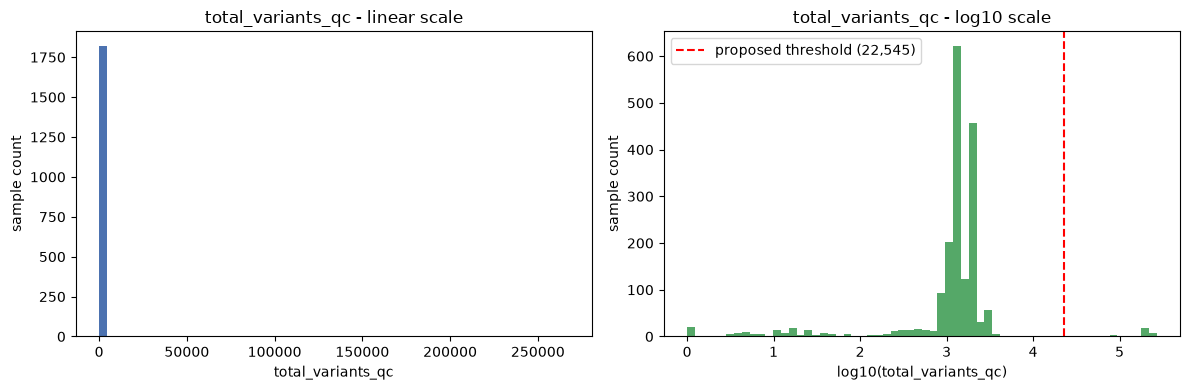

Saved: ../results/phaseA_qc_exploration/total_variants_qc_distribution.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y["total_variants_qc"], bins=60, color="#4C72B0")
axes[0].set_title("total_variants_qc - linear scale")
axes[0].set_xlabel("total_variants_qc")
axes[0].set_ylabel("sample count")

axes[1].hist(np.log10(y["total_variants_qc"].replace(0, 1)), bins=60, color="#55A868")
axes[1].set_title("total_variants_qc - log10 scale")
axes[1].set_xlabel("log10(total_variants_qc)")
axes[1].set_ylabel("sample count")
axes[1].axvline(np.log10(22545), color="red", linestyle="--", label="proposed threshold (22,545)")
axes[1].legend()

plt.tight_layout()
fig_path = os.path.join(OUT_DIR, "total_variants_qc_distribution.png")
plt.savefig(fig_path, dpi=150)
plt.show()
print(f"Saved: {fig_path}")

**Reading the gap:** the cohort's normal range tops out at 3,630, then
there's an 18,915-point jump straight to 22,545 - a clean bimodal split, not
a long tail. Everything above ~22,545 (267,483 at the max) is 60-200x the
typical sample. That's consistent with contamination, mixed infection, or a
misassembly, not real *M. tuberculosis* variant burden - this species is
genomically conserved; that many variants relative to H37Rv is not
biologically plausible for a clean single-strain isolate.

## 5. Does the QC-outlier cluster explain the `drtype` inconsistency?

In [7]:
QC_THRESHOLD = 22545  # sits in the 18,915-point gap identified above

high_qc = y[y["total_variants_qc"] > QC_THRESHOLD]
print(f"Samples above threshold ({QC_THRESHOLD}): {len(high_qc)}")
print()
print("drtype breakdown of high-QC samples:")
print(high_qc["drtype"].value_counts())
print()

non_susceptible = y[y["drtype"] != "Susceptible"]
zero_flags = (non_susceptible[binary_cols].sum(axis=1) == 0)
inconsistent = non_susceptible[zero_flags]

high_qc_ids = set(high_qc["sample_id"])
inconsistent_ids = set(inconsistent["sample_id"])

print(f"Inconsistent samples (drtype resistant, all binary flags 0): {len(inconsistent_ids)}")
print(f"  ...of which also high-QC:      {len(inconsistent_ids & high_qc_ids)}")
print(f"  ...inconsistent but NOT high-QC: {len(inconsistent_ids - high_qc_ids)}  <- unexplained by QC alone, needs separate follow-up")

Samples above threshold (22545): 36

drtype breakdown of high-QC samples:
drtype
HR-TB          26
Susceptible     5
Other           3
MDR-TB          1
Pre-XDR-TB      1
Name: count, dtype: int64

Inconsistent samples (drtype resistant, all binary flags 0): 42
  ...of which also high-QC:      25
  ...inconsistent but NOT high-QC: 17  <- unexplained by QC alone, needs separate follow-up


## Do any high-QC samples still contribute real-looking core mutations?

If so, they shouldn't be dropped outright from the mutation table - just
flagged as untrustworthy for phenotype-ground-truth comparisons
specifically.

In [8]:
high_qc_core_contributors = core[core["sample_id"].isin(high_qc_ids)]
print(f"High-QC samples that still contribute rows to core_set.csv: {high_qc_core_contributors['sample_id'].nunique()} / {len(high_qc_ids)}")
high_qc_core_contributors[["sample_id", "gene", "change", "drug"]]

High-QC samples that still contribute rows to core_set.csv: 6 / 36


,sample_id,gene,change,drug
1608,SRR33383939,rpoB,p.Ser431Thr,rifampicin
1609,SRR33383939,rpoB,p.Ser431Thr,rifapentine
1610,SRR33383939,rpoB,p.Asp435Gly,rifampicin
1611,SRR33383939,rpoB,p.Asp435Gly,rifapentine
1612,SRR33383939,rpoB,p.Leu452Pro,rifampicin
1613,SRR33383939,rpoB,p.Leu452Pro,rifapentine
1614,SRR33383939,rrs,n.1401A>G,amikacin
1615,SRR33383939,rrs,n.1401A>G,capreomycin
1616,SRR33383939,rrs,n.1401A>G,kanamycin
1617,SRR33383939,inhA,c.-770T>A,ethionamide


## Resolving the 17 samples not explained by QC alone

Section 5 found the QC-outlier cluster explains 25 of the 42 boundary-case
samples. This section investigates whether the remaining 17 have their own
explanation, or are a genuinely separate, unresolved problem.

In [9]:
unexplained_17 = inconsistent_ids - high_qc_ids
print(f"Unexplained (inconsistent but NOT high-QC): {len(unexplained_17)}")

for sid in sorted(unexplained_17):
    rows = df[df["sample_id"] == sid]
    confs = rows["confidence"].value_counts(dropna=False).to_dict()
    print(f"  {sid}: {len(rows)} dr_variants row(s) | confidence: {confs}")

Unexplained (inconsistent but NOT high-QC): 17
  SRR11947327: 3 dr_variants row(s) | confidence: {'Uncertain significance': 3}
  SRR11947499: 3 dr_variants row(s) | confidence: {'Uncertain significance': 3}
  SRR30519420: 5 dr_variants row(s) | confidence: {'Uncertain significance': 5}
  SRR30519454: 5 dr_variants row(s) | confidence: {'Uncertain significance': 5}
  SRR30519464: 5 dr_variants row(s) | confidence: {'Uncertain significance': 5}
  SRR30519475: 5 dr_variants row(s) | confidence: {'Uncertain significance': 5}
  SRR30519487: 5 dr_variants row(s) | confidence: {'Uncertain significance': 5}
  SRR32526358: 7 dr_variants row(s) | confidence: {'Uncertain significance': 7}
  SRR33384154: 2 dr_variants row(s) | confidence: {'Uncertain significance': 2}
  SRR33384162: 2 dr_variants row(s) | confidence: {'Uncertain significance': 2}
  SRR34092684: 4 dr_variants row(s) | confidence: {'Uncertain significance': 4}
  SRR36942120: 2 dr_variants row(s) | confidence: {'Uncertain significanc

**Result:** all 17 have exclusively `Uncertain significance` rows (16 of
them) or exactly one `NaN`-confidence row (`SRR36942163`, the same
rpoB p.Leu464Met/rifampicin case from Section 4). None have a `Not assoc w R`
row, and by definition none have a core-set row.

This resolves the mystery completely, and reframes Section 5's QC finding:
the QC-outlier cluster was never the primary mechanism - it was a partial,
correlated signal. The actual mechanism, true for **all 42** boundary
samples without exception, is that TB-Profiler's own sample-level `drtype`
call uses a more permissive evidence threshold than this project's core
set: it can classify a sample as resistant on the strength of an
`Uncertain significance` (or unlabelled) variant alone, even though that
same variant hasn't cleared the bar for `Assoc w R` at the per-variant
level. The 25/42 that also happened to be QC outliers were never a
different category - they're just samples where a messy sequencing run
produced enough extra `Uncertain significance` calls to make the same
mechanism visible. Checking that directly:

In [10]:
unc_per_sample = df[df["confidence"] == "Uncertain significance"].groupby("sample_id").size()
y_tmp = y.merge(unc_per_sample.rename("n_uncertain_rows"), left_on="sample_id", right_index=True, how="left")
y_tmp["n_uncertain_rows"] = y_tmp["n_uncertain_rows"].fillna(0)

high_qc_mask = y_tmp["total_variants_qc"] > QC_THRESHOLD
print("Mean Uncertain-significance rows per sample:")
print(f"  High-QC samples    (n={high_qc_mask.sum()}): {y_tmp[high_qc_mask]['n_uncertain_rows'].mean():.1f}")
print(f"  Normal-QC samples  (n={(~high_qc_mask).sum()}): {y_tmp[~high_qc_mask]['n_uncertain_rows'].mean():.2f}")

Mean Uncertain-significance rows per sample:
  High-QC samples    (n=36): 4.6
  Normal-QC samples  (n=1822): 1.90


High-QC samples do carry more `Uncertain significance` calls on average
(4.6 vs 1.9) - consistent with messier sequencing generating more spurious
low-confidence calls generally - but the effect is modest, not dominant
(the single highest per-sample count, 18, actually belongs to a
*normal*-QC sample). QC status is a partial correlate of this pattern, not
its cause. The real, complete explanation is simpler and applies uniformly:
**TB-Profiler's `drtype` field is not restricted to the same evidence tier
this project's core set uses.** Any Objective 1 test that treats `drtype`
or the per-drug categorical columns as ground truth needs to know that,
independent of any QC consideration.

## Build the QC-flag lookup table

Not a filter applied silently - a table Objective 1 (and any other step
using `drtype`/phenotype columns as ground truth) must explicitly join
against and decide how to use.

In [ ]:
qc_flags = y[["sample_id", "drtype", "total_variants_qc"]].copy()
qc_flags["high_variant_qc"] = qc_flags["total_variants_qc"] > QC_THRESHOLD

phenotype_inconsistent = set(inconsistent["sample_id"])
qc_flags["phenotype_binary_inconsistent"] = qc_flags["sample_id"].isin(phenotype_inconsistent)

qc_flags["has_core_mutation"] = qc_flags["sample_id"].isin(core_samples)

# Documents WHY a sample is phenotype-inconsistent, not just THAT it is - resolved directly in Section 7: every inconsistent sample's drtype rests
# on an Uncertain-significance row, except one on a single unlabelled (NaN-confidence) row. Never on a Not-assoc-w-R row, never unexplained.
def inconsistency_source(sid):
    if sid not in phenotype_inconsistent:
        return None
    rows = df[df["sample_id"] == sid]
    confs = set(rows["confidence"].dropna().unique())
    if "Uncertain significance" in confs:
        return "uncertain_significance_evidence"
    if rows["confidence"].isna().any():
        return "unlabelled_confidence_evidence"
    return "unresolved"  # should not occur - flags a genuinely new case if it ever does

qc_flags["phenotype_inconsistency_source"] = qc_flags["sample_id"].apply(inconsistency_source)

qc_flags["recommended_exclude_from_phenotype_ground_truth"] = (
    qc_flags["high_variant_qc"] | qc_flags["phenotype_binary_inconsistent"]
)

n_unresolved = (qc_flags["phenotype_inconsistency_source"] == "unresolved").sum()
print(qc_flags["recommended_exclude_from_phenotype_ground_truth"].sum(), "samples flagged")
print(qc_flags["phenotype_inconsistency_source"].value_counts(dropna=False))
assert n_unresolved == 0, f"{n_unresolved} sample(s) have no identified inconsistency source - investigate before trusting this table."
qc_flags[qc_flags["recommended_exclude_from_phenotype_ground_truth"]].sort_values(
    "total_variants_qc", ascending=False
).head(10)

53 samples flagged
phenotype_inconsistency_source
NaN                                1816
uncertain_significance_evidence      41
unlabelled_confidence_evidence        1
Name: count, dtype: int64


,sample_id,drtype,total_variants_qc,high_variant_qc,phenotype_binary_inconsistent,has_core_mutation,phenotype_inconsistency_source,recommended_exclude_from_phenotype_ground_truth
1273,SRR33384565,Other,267483,True,True,False,uncertain_significance_evidence,True
1221,SRR33384513,HR-TB,261607,True,False,True,NaN,True
1232,SRR33384524,HR-TB,259362,True,False,True,NaN,True
707,SRR33383998,HR-TB,258601,True,True,False,uncertain_significance_evidence,True
843,SRR33384135,HR-TB,256740,True,True,False,uncertain_significance_evidence,True
1231,SRR33384523,HR-TB,254136,True,False,True,NaN,True
642,SRR33383933,HR-TB,232006,True,True,False,uncertain_significance_evidence,True
1083,SRR33384375,HR-TB,209892,True,True,False,uncertain_significance_evidence,True
752,SRR33384044,HR-TB,200966,True,True,False,uncertain_significance_evidence,True
1315,SRR33384607,HR-TB,200921,True,False,True,NaN,True


In [12]:
out_path = os.path.join(OUT_DIR, "qc_flagged_samples.csv")
qc_flags.to_csv(out_path, index=False)
print(f"Written: {out_path}  ({len(qc_flags)} rows, one per cohort sample)")

Written: ../results/phaseA_qc_exploration/qc_flagged_samples.csv  (1858 rows, one per cohort sample)


## Summary

- 36 samples have `total_variants_qc > 22,545` - a clean, well-separated
  outlier cluster (cohort's normal range tops out at 3,630).
- 26 of those 36 are labeled `drtype == HR-TB` despite `isoniazid_binary == 0`
  and every other per-drug binary column also reading 0.
- Cohort-wide, 31 of 85 total HR-TB-labeled samples have this inconsistency --
  broader than the 26-sample subset inside the original 42-sample boundary
  case.
- **All 42 boundary-case samples are now fully explained**: every one rests
  on an `Uncertain significance` row (41 samples) or a single unlabelled
  `NaN`-confidence row (1 sample, `SRR36942163`) - never on a confirmed
  `Assoc w R` row and never unresolved. The QC-outlier cluster (25 of the 42)
  is a partial correlate, not the mechanism itself; the other 17 are normal-QC
  samples where the same Uncertain-significance-driven `drtype` behaviour
  shows up independent of any sequencing-quality issue.
- 6 high-QC samples still carry real-looking core-set mutations (coherent
  MDR-pattern combinations) -- they stay in `core_set.csv` for mutation-level
  analysis, but are flagged out of phenotype-ground-truth comparisons.
- **Decision for Objective 1:** use `qc_flagged_samples.csv`'s
  `recommended_exclude_from_phenotype_ground_truth` column to exclude flagged
  samples from the confirmatory Fisher's test's phenotype ground truth -
  now with `phenotype_inconsistency_source` documenting exactly why each one
  was flagged, not just that it was.